<a href="https://colab.research.google.com/github/MarcinJanis/SonarOdometry/blob/main/notebooks/test/odometry2d_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
!pip install pypose
!pip install kornia

In [3]:
!git clone https://github.com/MarcinJanis/SonarOdometry.git



Cloning into 'SonarOdometry'...
remote: Enumerating objects: 3952, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 3952 (delta 45), reused 0 (delta 0), pack-reused 3872 (from 2)
Receiving objects: 100% (3952/3952), 565.14 MiB | 22.40 MiB/s, done.
Resolving deltas: 100% (1298/1298), done.
Updating files: 100% (241/241), done.


In [4]:
%cd SonarOdometry


/content/SonarOdometry


In [5]:
from google.colab import drive
# !unzip -q /content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample.zip -d /content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import sys

import cv2

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random

import time

from tqdm import tqdm

# root_dir = os.path.abspath('../..')
# if root_dir not in sys.path:
#     sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
# from src.models.patchifier import Patchifier

# from training.utils import pose_err


In [7]:
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
root_dir = '/content/SonarOdometry'

model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')

# data_root_dir = os.path.join(root_dir, 'SonarOdometryDataset/supervised/val/seq_14')
data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])


from src.data_loader.transforms import SonarDatasetTranforms


fls_resolution = (model_config.FLS_INPUT_HEIGHT, model_config.FLS_INPUT_WIDTH)

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = extrinsics_calib)
data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')



Data generator initialized.
Data series lenght: 1000


In [8]:
def visualize_loftr_matches(visu, num_matches=100):
    """
    Wizualizuje dopasowania punktów kluczowych LoFTR.
    visu: słownik z kluczami 'combined_imgs', 'pts1', 'pts2', 'pts2_offset'
    """
    img = visu['combined_imgs']
    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1]

    if len(pts1) == 0:
        print("Brak dopasowań do wyświetlenia!")
        return

    # Losowy wybór punktów dla czytelności
    n = min(len(pts1), num_matches)
    indices = np.random.choice(len(pts1), n, replace=False)

    fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
    ax.imshow(img)

    for i in indices:
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]

        # Przesunięcie drugiego zbioru punktów o szerokość pierwszej klatki
        ax.plot([x1, x2 + offset_x], [y1, y2], color='cyan', linewidth=0.8, alpha=0.5)
        ax.plot(x1, y1, 'ro', markersize=3)
        ax.plot(x2 + offset_x, y2, 'go', markersize=3)

    ax.set_title(f'Dopasowania LoFTR (wyświetlono {n} z {len(pts1)} punktów)')
    ax.axis('off')
    plt.show()

In [9]:
from src.models.odometry2d import sonar_odometry
model = sonar_odometry(model_config, sonar_config, device = device)


In [15]:
import torch

# --- init ---
start_idx = 400
max_iter = 25

# Fix: Ensure extrinsics_calib internal tensors are on the correct device
# The extrinsics_calib object's internal LieTensors (se3_s2r, se3_r2s) were initialized on CPU.
# This block ensures they are moved to the designated 'device' (likely CUDA) before use.
if hasattr(extrinsics_calib, 'se3_s2r') and isinstance(extrinsics_calib.se3_s2r, torch.Tensor) and extrinsics_calib.se3_s2r.device != device:
    extrinsics_calib.se3_s2r = extrinsics_calib.se3_s2r.to(device)
if hasattr(extrinsics_calib, 'se3_r2s') and isinstance(extrinsics_calib.se3_r2s, torch.Tensor) and extrinsics_calib.se3_r2s.device != device:
    extrinsics_calib.se3_r2s = extrinsics_calib.se3_r2s.to(device)


# data containers
gt_xy = []
pred_xy = []


# set initial state
t, frame, pose_gt, depth = data_generator.get_sample(start_idx, return_visu=False, return_depth=True)

# init pose (x, y)
init_xy = pose_gt[0:2].detach().cpu().numpy()
gt_xy.append(pose_gt[0:2])
pred_xy.append(pose_gt[0:2].detach().cpu().numpy())

# init azimuth
rot = R.from_quat(pose_gt[3:7].detach().cpu().numpy())
euler = rot.as_euler('zyx', degrees=False)
init_azimuth = euler[0] # yaw

init_frame = frame.squeeze(1).to(device)

model.set_init_state(init_xy[0], init_xy[1], init_azimuth, init_frame)

# --- main loop ---

for i in tqdm(range(start_idx, start_idx + max_iter), desc="Sonar odometry"):

    t, frame, pose_gt, depth = data_generator.get_sample(i, return_visu=False, return_depth=True)

    pred_pose, pred_azimuth, visu = model(frame.squeeze(1).to(device), depth.to(device), return_visu = True)
    if i == 210:
      visualize_loftr_matches(visu, num_matches=100)

    gt_xy.append(pose_gt[0:2])
    pred_xy.append(pred_pose)


gt_xy_np = torch.stack(gt_xy).cpu().numpy()
pred_xy_np = np.array(pred_xy)


Sonar odometry: 100%|██████████| 25/25 [00:28<00:00,  1.15s/it]


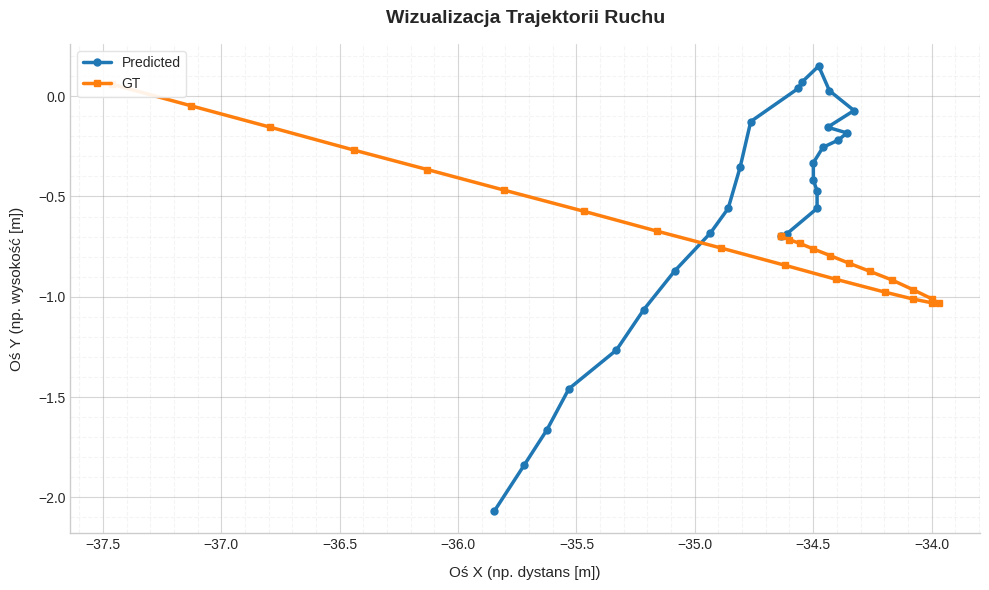

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

x1 = pred_xy_np[:, 0]
y1 = pred_xy_np[:, 1]
x2 = gt_xy_np[:, 0]
y2 = gt_xy_np[:, 1]

ax.plot(x1, y1, label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(x2, y2, label='GT', linewidth=2.5, marker='s', markersize=5)


# 5. Konfiguracja drobnej siatki (Minor Grid)
ax.minorticks_on()  # włączenie mniejszych podziałek na osiach
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

# 6. Podpisy osi i tytuł (z ładnym fontem i odstepami)
ax.set_title('Wizualizacja Trajektorii Ruchu', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Oś X (np. dystans [m])', fontsize=11, labelpad=10)
ax.set_ylabel('Oś Y (np. wysokość [m])', fontsize=11, labelpad=10)

# 7. Stylizacja legendy i obramowania
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

# Usunięcie zbędnych ramek (górnej i prawej) dla lżejszego wyglądu
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Automatyczne dopasowanie marginesów
plt.tight_layout()

# 8. Wyświetlenie wykresu
plt.show()